In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as dist
import torch.nn as nn

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid

import itertools

%matplotlib inline

# Fitting a variational auto-encoder

Download the data and plot a few images.

In [ ]:
# Download the dataset and apply necessary transformations

mnist_transforms = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.round())])
mnist_dataset = MNIST(root='data/', download=True, train=True, transform=mnist_transforms)
train_loader = torch.utils.data.DataLoader(mnist_dataset, batch_size=100, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.6MB/s]


## Data format

Each MNIST image $x_i$ is a **binary image** with shape `(1, 28, 28)`, i.e.

$$x_i \in \{0, 1\}^{1\times28\times28}$$

The first dimension is the number of "channels". It is `1` because these are black-and-white images. (For color images, there are three channels.)

The convention in pytorch is for images to be `[channels][rows][columns]`. This is different than numpy, which you might be familiar with, which instead has `[rows][columns][channels]`. We will have to call `torch.permute` to re-arrange the axes, sometimes.

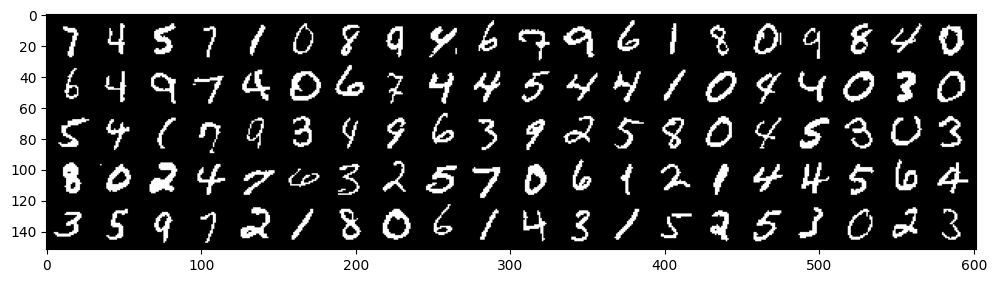

In [ ]:
plt.figure(figsize=(12,5))
X_random_batch, y_random_batch = next(iter(train_loader))
plt.imshow(make_grid(X_random_batch, nrow=20).permute(1,2,0));

Define encoder and decoder networks

We have data $x_i$ and will learn a latent representation $z_i \in \mathbb{R}^{D}$.

To do this we define two different networks, each as an `nn.Module` instance.


* The **Encoder** defines an inference network. It takes a batch of data instances as inputs, and returns a probability distribution $q(z_i | x_i)$ for each $x_i$ in the batch.
* The **Decoder** defines the likelihood in a generative model. It takes a latent value as input, and returns a probability distribution $p(x_i | z_i)$.


In [ ]:
class Encoder(nn.Module):

    def __init__(self, D_latent):
        """
        Initialize the Encoder `nn.Module`.

        This will operate on inputs of shape (batch_size, 1, 28, 28).

        INPUTS:
        D_latent: size of latent space (integer)

        """
        super().__init__()
        self.D_latent = D_latent

        self.encode = nn.Sequential(
            # Get basic features: lines, curves, and different angles of
            nn.Conv2d(1, 16, kernel_size=3, stride=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Look at the average in an area
            nn.MaxPool2d(kernel_size=2),
            # Get more complex features: collections of lines and circles
            nn.Conv2d(16, 32, kernel_size=3, stride=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Flatten to feature space
            nn.Flatten(),
            # Convert channels to richer latent space
            nn.Linear(32 * 2 * 2, 32),
            # Convert latent space to mean and log standard deviation
            nn.Linear(32, 2 * D_latent)
        )

    def forward(self, X):
        """ Return a distribution q(z | x).

        Remember you can access and variables or `nn.Module` instances defined in the constructor.

        INPUT:
        X    : torch.FloatTensor containing zeros and ones; shape = (batch_size, 1, 28, 28)

        OUTPUT: a `torch.Distribution` instance, defined on values of shape = (batch_size, D_latent)
        """
        # Encode image as mean and log variance (so unconstrained in model)
        mu, log_sigma = torch.split(self.encode(X), self.D_latent, dim=1)
        sigma = torch.exp(log_sigma)

        assert mu.shape == (X.shape[0], self.D_latent)
        assert mu.shape == sigma.shape
        return dist.Normal(mu, sigma)


In [ ]:
from prettytable import PrettyTable

def count_parameters(model):
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0
    for name, parameter in model.named_parameters():
        # if not parameter.requires_grad:
        #     continue
        params = parameter.numel()
        table.add_row([name, params])
        total_params += params
    print(table)
    print(f"Total Trainable Params: {total_params}")
    return total_params

count_parameters(Encoder(10))

+-----------------+------------+
|     Modules     | Parameters |
+-----------------+------------+
| encode.0.weight |    144     |
|  encode.0.bias  |     16     |
| encode.1.weight |     16     |
|  encode.1.bias  |     16     |
| encode.4.weight |    4608    |
|  encode.4.bias  |     32     |
| encode.5.weight |     32     |
|  encode.5.bias  |     32     |
| encode.8.weight |    4096    |
|  encode.8.bias  |     32     |
| encode.9.weight |    640     |
|  encode.9.bias  |     20     |
+-----------------+------------+
Total Trainable Params: 9684


9684

In [ ]:
class Decoder(nn.Module):

    def __init__(self, D_latent):
        """
        Initialize the Decoder `nn.Module`.

        This will operate on inputs of shape (batch_size, D_latent).

        INPUTS:
        D_latent: size of latent space (integer)

        """
        super().__init__()
        self.D_latent = D_latent
        self.c_start = 6

        # Expand latent space to vector of features
        self.expand = nn.Sequential(
            nn.Linear(self.D_latent, 7 * 7 * self.c_start),
        )

        self.generate = nn.Sequential(
            # Produce a better estimate based on channels and info
            nn.Conv2d(self.c_start, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Expand canvas
            nn.UpsamplingBilinear2d((15,15)),
            # Produce low res image
            nn.Conv2d(32, 16, 3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Expand canvas
            nn.UpsamplingBilinear2d((30,30)),
            # Produce final image distribution
            nn.Conv2d(16, 1, 3),
            nn.BatchNorm2d(1),
            # Produce pseudo-probability
            nn.Sigmoid()
        )

    def forward(self, Z):
        """ Return a distribution p(x | z)

        INPUT:
        X    : torch.FloatTensor, real-valued, shape = (batch_size, D_latent)

        OUTPUT: a `torch.Distribution` instance, defined on values of shape = (batch_size, 1, 28, 28)
        """
        features = self.expand(Z).reshape(-1,self.c_start,7,7)
        X_hat = self.generate(features)

        return dist.Bernoulli(X_hat)


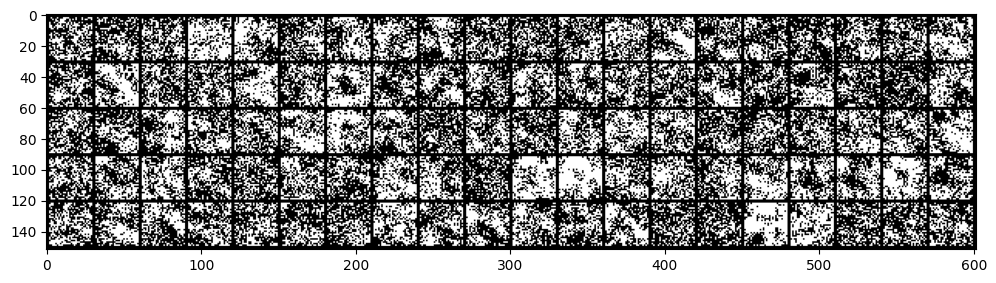

In [ ]:
X_random_batch, _ = next(iter(train_loader))
latent_dim = 10
enc = Encoder(latent_dim)
dec = Decoder(latent_dim)

latents = enc(X_random_batch).sample()

plt.figure(figsize=(12,5))
plt.imshow(make_grid(dec(latents).sample(), nrow=20).permute(1,2,0));

In [ ]:
count_parameters(Decoder(10))

+-------------------+------------+
|      Modules      | Parameters |
+-------------------+------------+
|  expand.0.weight  |    2940    |
|   expand.0.bias   |    294     |
| generate.0.weight |    1728    |
|  generate.0.bias  |     32     |
| generate.1.weight |     32     |
|  generate.1.bias  |     32     |
| generate.4.weight |    4608    |
|  generate.4.bias  |     16     |
| generate.5.weight |     16     |
|  generate.5.bias  |     16     |
| generate.8.weight |    144     |
|  generate.8.bias  |     1      |
| generate.9.weight |     1      |
|  generate.9.bias  |     1      |
+-------------------+------------+
Total Trainable Params: 9861


9861

# Define the objective function


In [ ]:
def ELBO_VAE(enc, dec, X):
    """

    INPUT:
    enc : Instance of `Encoder` class, which returns a distribution
          over Z when called on a batch of inputs X
    dec : Instance of `Decoder` class, which returns a distribution
          over X when called on a batch of inputs Z
    X   : A batch of datapoints, torch.FloatTensor of shape = (batch_size, 1, 28, 28)


    OUTPUT: a torch.FloatTensor of shape = (batch_size, ) containing the estimate
            of the per-datapoint ELBO for every data point in the batch.

    """
    # Distributions
    prior = dist.MultivariateNormal(torch.zeros(enc.D_latent),torch.eye(enc.D_latent))
    posterior = enc(X)

    # Get a **single sample** of reparameterised q(z|x)
    latent_sample = posterior.rsample()

    # Calculate log probabilities
    log_qz = prior.log_prob(latent_sample)
    log_qz_x = posterior.log_prob(latent_sample)
    log_qx_z = dec(latent_sample).log_prob(X)

    # Assuming that X is i.i.d, the latent variables are i.i.d and the pixels are i.i.d
    return log_qz + log_qx_z.sum((1,2,3)) - log_qz_x.sum(1)


In [ ]:
latent_dim = 2
enc = Encoder(latent_dim)
dec = Decoder(latent_dim)
X, _ = next(iter(train_loader))
ELBO_VAE(enc, dec, X)

tensor([ -558.4355,  -591.5195,  -636.7407,  -529.0328,  -548.2101,  -808.3879,
         -600.4364,  -587.7467,  -613.9459,  -589.2798,  -843.9426,  -553.8195,
         -604.5626,  -643.7122,  -618.2512,  -599.5667,  -654.1301,  -685.8990,
         -759.5107,  -564.9818,  -597.6985,  -578.1904,  -815.9879,  -561.8810,
         -553.2527,  -646.4124,  -601.1315,  -550.1135,  -578.1893,  -585.4180,
         -623.1837,  -624.2093,  -870.5089,  -648.6575,  -580.5499,  -600.9871,
         -600.0582,  -607.1461,  -587.1689,  -833.1664,  -578.5814,  -724.3729,
         -580.9377,  -549.6937,  -636.6354,  -607.0679,  -734.9825,  -634.9398,
         -581.4424, -1026.5669,  -579.7649,  -595.9910,  -704.1288,  -622.6884,
         -636.7969,  -589.2156,  -575.6602,  -572.8712, -1243.1671,  -572.1947,
         -529.8829,  -705.9066,  -623.0656,  -634.0122,  -676.3373,  -588.9324,
         -586.1170,  -727.6643,  -779.2717,  -817.0133,  -593.2673,  -624.3478,
         -811.4987,  -560.9146,  -590.76

# Train the VAE

In [ ]:
# Try modifying this and seeing how it affects performance!
D_latent = 2

enc = Encoder(D_latent)
dec = Decoder(D_latent)

opt_vae = torch.optim.Adam(itertools.chain(enc.parameters(), dec.parameters()))

In [ ]:
def run_training(N_epochs, enc, dec):
    """ Outer loop for training the VAE

        Calls your `ELBO_VAE` function!
    """
    for epoch in range(N_epochs):
        train_loss = 0.0
        for (X, _) in train_loader:
            opt_vae.zero_grad()

            # Call you ELBO implementation
            elbos = ELBO_VAE(enc, dec, X)

            # Please don't break the following assertion (check your return shape!)
            batch_size = X.shape[0]
            assert elbos.shape == (batch_size,)

            # The loss is the sum of the negative per-datapoint ELBO
            loss = -elbos.sum()
            loss.backward()
            opt_vae.step()
            train_loss += loss.item() * X.shape[0] / len(mnist_dataset)
        print("Epoch %d, train loss = %0.4f" % (epoch, train_loss));

In [ ]:
N_epochs = 15 # Note that you may want to run more epochs!
run_training(N_epochs, enc, dec)

Epoch 0, train loss = 40303.0775
Epoch 1, train loss = 29618.1818
Epoch 2, train loss = 24256.9657
Epoch 3, train loss = 21150.3040
Epoch 4, train loss = 19252.6190
Epoch 5, train loss = 18057.6951
Epoch 6, train loss = 17271.1699
Epoch 7, train loss = 16750.1881
Epoch 8, train loss = 16399.1591
Epoch 9, train loss = 16134.3462
Epoch 10, train loss = 15964.9756
Epoch 11, train loss = 15827.7542
Epoch 12, train loss = 15725.4441
Epoch 13, train loss = 15648.2660
Epoch 14, train loss = 15592.1912


## Do reconstructions look like the input?

Reconstruction accuracy: 0.87


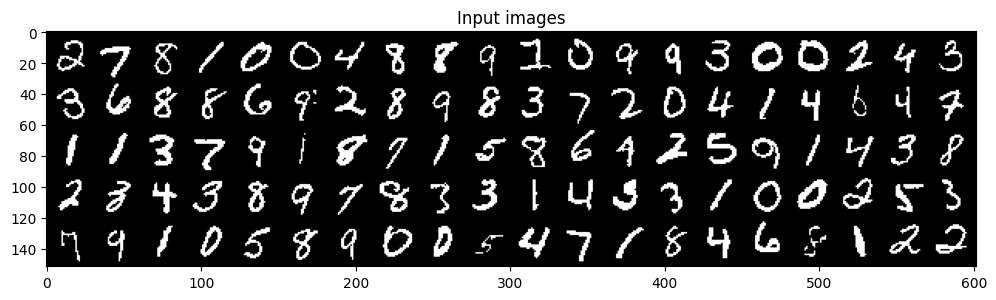

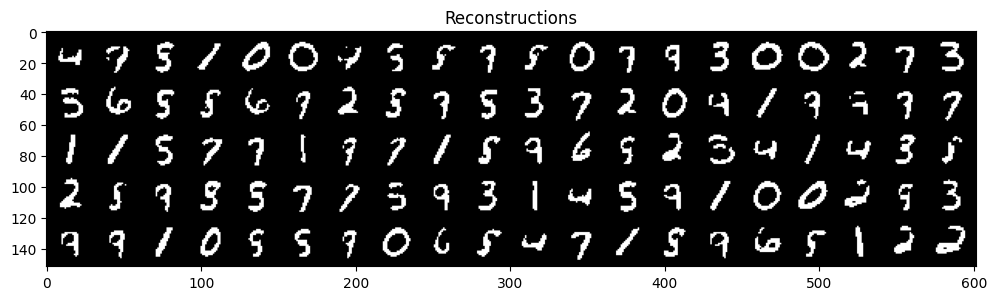

In [ ]:
plt.figure(figsize=(12, 4))
plt.imshow(make_grid(X_random_batch, nrow=20).permute(1,2,0))
plt.title("Input images")
plt.figure(figsize=(12, 4))
plt.title("Reconstructions")
with torch.no_grad():
    plt.imshow(make_grid(dec(enc(X_random_batch).sample()).mean.round(), nrow=20).permute(1,2,0))

print("Reconstruction accuracy: %0.2f" % (X_random_batch == dec(enc(X_random_batch).sample()).sample()).float().mean().item())

## Do randomly generated samples look coherent?

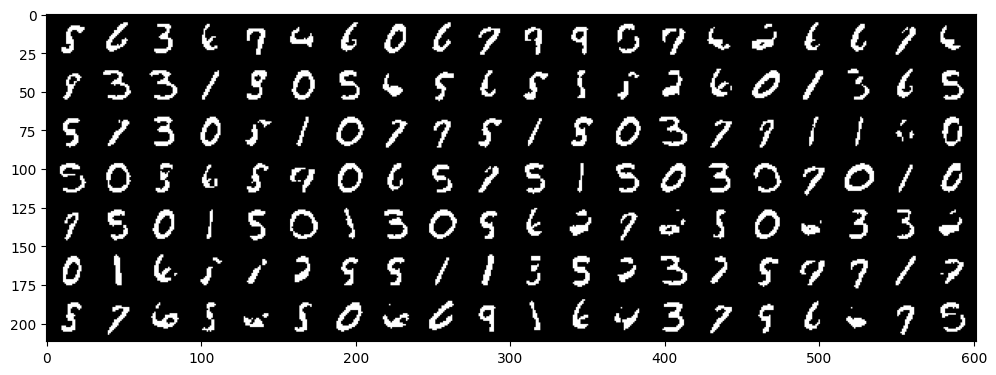

In [ ]:
plt.figure(figsize=(12,5))
with torch.no_grad():
    plt.imshow(make_grid(dec(dist.Normal(0, 1).sample((140, D_latent))).mean.round(), nrow=20).permute(1,2,0), vmin=0, vmax=1)

## What does the latent space look like?

Note that this will only give sensible plots for very low-dimensional latent spaces. It works best if the latent space is actually 2d. Otherwise, it will plot a 2d cross-section that may or may not be informative.

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


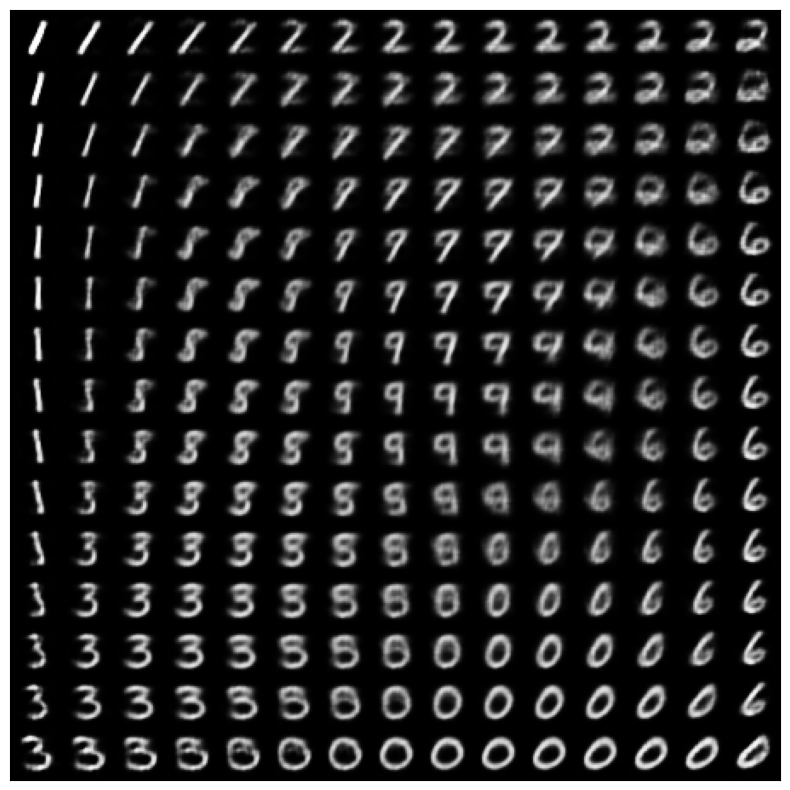

In [ ]:
def plot_2d_latent(encoder, decoder):
    """ If this is a 2d latent space, it plots the latent space
        If the latent space is larger than 2d, then it plots a 2d cross-section """
    W = torch.linalg.svd(encoder(X_random_batch).mean).Vh[:2]
    points = dist.Normal(0, 1).icdf(torch.linspace(0.01, 0.99, 15))
    XX, YY = torch.meshgrid(points, points)
    XXYY = torch.stack((XX, YY)).reshape(2, -1).T
    with torch.no_grad():
        out = dec(XXYY @ W).mean
    plt.imshow(make_grid(out, nrow=len(points)).permute(1,2,0))
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(10, 10))
out = plot_2d_latent(enc, dec)

In [ ]:
X_random_batch, y_random_batch = next(iter(train_loader))
print(y_random_batch)

tensor([7, 7, 2, 7, 7, 5, 8, 4, 4, 8, 0, 1, 3, 1, 9, 4, 1, 8, 4, 2, 2, 7, 7, 1,
        5, 4, 0, 1, 9, 6, 4, 0, 3, 6, 5, 6, 1, 9, 8, 1, 4, 5, 9, 4, 5, 9, 0, 6,
        3, 1, 0, 4, 5, 2, 5, 4, 8, 4, 6, 5, 0, 5, 9, 1, 2, 4, 3, 0, 9, 3, 1, 4,
        2, 5, 4, 4, 9, 2, 7, 7, 7, 4, 7, 2, 5, 4, 7, 9, 3, 4, 6, 0, 4, 8, 6, 0,
        3, 6, 4, 3])


In [ ]:

class LatentClassifier(nn.Module):

    def __init__(self, D_latent, num_classes):
        super().__init__()
        self.D_latent = D_latent
        self.classify = nn.Sequential(
            nn.Linear(D_latent, num_classes),
            nn.Softmax()
        )

    def forward(self, X):
        return self.classify(X)


In [ ]:
cls = LatentClassifier(D_latent, 10)

opt_cls = torch.optim.Adam(cls.parameters())
criterion = nn.CrossEntropyLoss()

def train_classifier(N_epochs, enc, cls):
    """ Outer loop for training the VAE

        Calls your `ELBO_VAE` function!
    """
    # Freeze the encoder to prevent it being corrupted
    enc.train(False)

    for epoch in range(N_epochs):
        train_loss = 0.0
        for (X, y) in train_loader:
            opt_cls.zero_grad()

            output = cls(enc(X).sample())
            label = nn.functional.one_hot(y, num_classes=10)

            # The loss is the sum of the negative per-datapoint ELBO
            loss = criterion(output, y)
            loss.backward()
            opt_cls.step()
            train_loss += loss.item() / len(train_loader)
        print("Epoch %d, train loss = %0.4f" % (epoch, train_loss));

    # Return trainability to prevent unexpected behaviour
    enc.train(True)

In [ ]:
train_classifier(20, enc, cls)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 0, train loss = 2.2646
Epoch 1, train loss = 2.1826
Epoch 2, train loss = 2.1034
Epoch 3, train loss = 2.0586
Epoch 4, train loss = 2.0247
Epoch 5, train loss = 2.0020
Epoch 6, train loss = 1.9842
Epoch 7, train loss = 1.9697
Epoch 8, train loss = 1.9580
Epoch 9, train loss = 1.9481
Epoch 10, train loss = 1.9395
Epoch 11, train loss = 1.9317
Epoch 12, train loss = 1.9246
Epoch 13, train loss = 1.9183
Epoch 14, train loss = 1.9127
Epoch 15, train loss = 1.9074
Epoch 16, train loss = 1.9029
Epoch 17, train loss = 1.8990
Epoch 18, train loss = 1.8953
Epoch 19, train loss = 1.8918


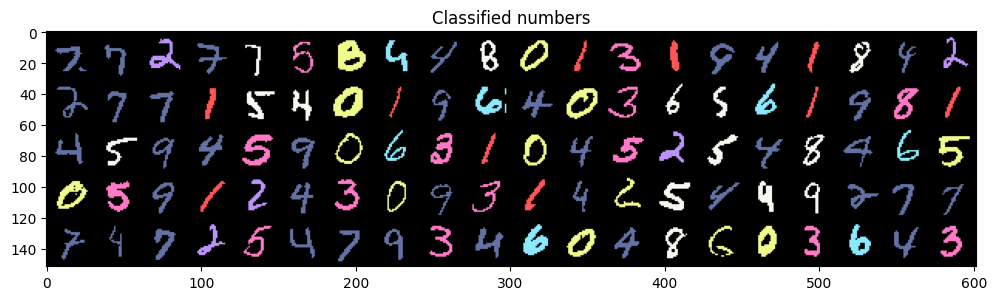

In [ ]:
def num_to_colour(preds):
    nums = torch.argmax(preds, dim=1)

    black = torch.tensor([[0, 0, 0]]).expand(nums.size(0),-1)
    c_zero = torch.tensor([[241,250,140]]).expand(nums.size(0),-1)
    c_one = torch.tensor([[255,85,85]]).expand(nums.size(0),-1)
    c_two = torch.tensor([[189,147,249]]).expand(nums.size(0),-1)
    c_three = torch.tensor([[255,121,198]]).expand(nums.size(0),-1)
    c_four = torch.tensor([[255,184,108]]).expand(nums.size(0),-1)
    c_five = torch.tensor([[80,250,123]]).expand(nums.size(0),-1)
    c_six = torch.tensor([[139,233,253]]).expand(nums.size(0),-1)
    c_seven = torch.tensor([[98,114,164]]).expand(nums.size(0),-1)
    c_eight = torch.tensor([[248,248,242]]).expand(nums.size(0),-1)
    c_nine = torch.tensor([[68,71,90]]).expand(nums.size(0),-1)

    colour_nums = nums.unsqueeze(-1).expand(-1, 3)
    cmap = torch.where(colour_nums == 0, c_zero, black)
    cmap = torch.where(colour_nums == 1, c_one, cmap)
    cmap = torch.where(colour_nums == 2, c_two, cmap)
    cmap = torch.where(colour_nums == 3, c_three, cmap)
    cmap = torch.where(colour_nums == 4, c_four, cmap)
    cmap = torch.where(colour_nums == 5, c_five, cmap)
    cmap = torch.where(colour_nums == 6, c_six, cmap)
    cmap = torch.where(colour_nums == 7, c_seven, cmap)
    cmap = torch.where(colour_nums == 8, c_eight, cmap)
    cmap = torch.where(colour_nums == 9, c_nine, cmap)

    return cmap.unsqueeze(-1).unsqueeze(-1)

plt.figure(figsize=(12, 4))
plt.title("Classified numbers")
with torch.no_grad():
    sample = enc(X_random_batch).sample()
    rgb_img = X_random_batch.round().expand(-1,3,-1,-1)
    cmap = num_to_colour(cls(sample)).expand(-1,-1,28,28)
    #print(rgb_img.size(), cmap.size())
    rgb_img = (rgb_img * cmap) / 255
    plt.imshow(make_grid(rgb_img, nrow=20).permute(1,2,0))
    #print(torch.argmax(cls(sample), dim=1).reshape(-1,20))

/tmp/ipython-input-2558228264.py:30: UserWarning: Legend does not support handles for int64 instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend(np.arange(10), ['0','1','2','3','4','5','6','7','8','9'], loc="best")


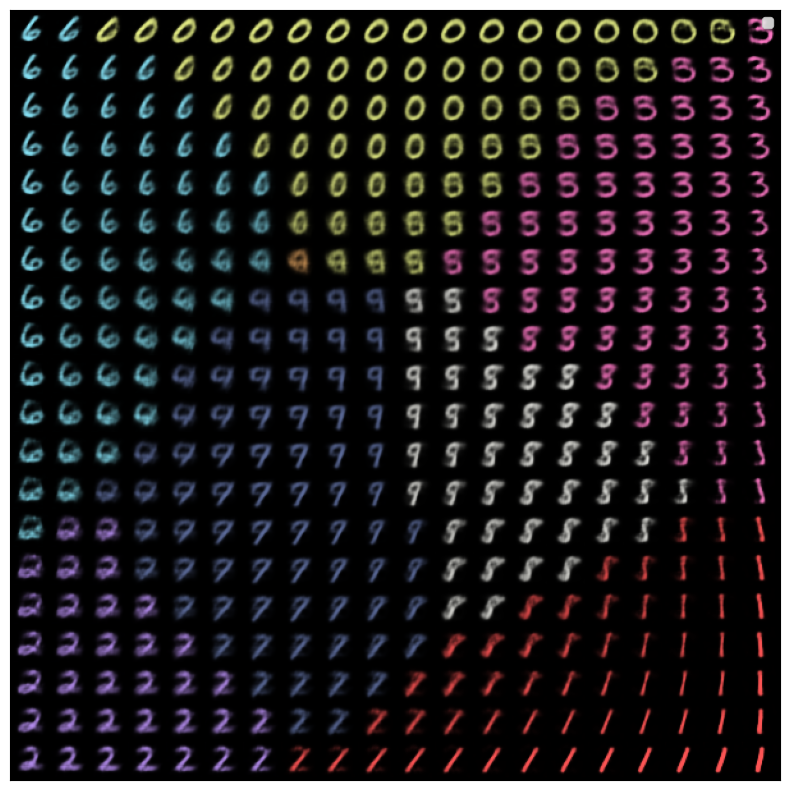

In [ ]:
def plot_2d_latent_with_class(encoder, decoder, classifier):
    W = torch.linalg.svd(encoder(X_random_batch).mean).Vh[:2]
    points = dist.Normal(0, 1).icdf(torch.linspace(0.01, 0.99, 20))
    XX, YY = torch.meshgrid(points, points)
    XXYY = torch.stack((XX, YY)).reshape(2, -1).T
    with torch.no_grad():
        latent = XXYY @ W
        out = decoder(latent).mean.expand(-1,3,-1,-1)
        num = classifier(latent)
        cmap = num_to_colour(cls(latent)).expand(-1,-1,28,28)
        out = (out * cmap) / 255
    plt.imshow(make_grid(out, nrow=len(points)).permute(1,2,0))


plt.figure(figsize=(10, 10))
plt.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)
plt.tick_params(
    axis='y',
    which='both',
    left=False,
    right=False,
    labelleft=False
)
plt.legend(np.arange(10), ['0','1','2','3','4','5','6','7','8','9'], loc="best")
out = plot_2d_latent_with_class(enc, dec, cls)

In [ ]:
%matplotlib qt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 115.6 MB/s eta 0:00:00
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


ImportError: Failed to import any of the following Qt binding modules: PyQt5, PySide2

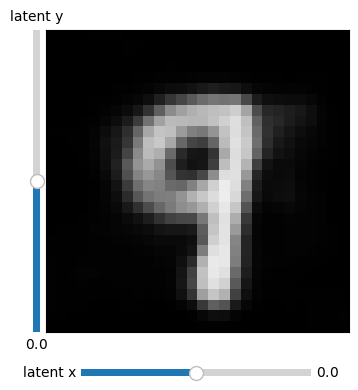

In [ ]:
from matplotlib.widgets import Slider

def latent_to_img(latent_point, decoder):
    with torch.no_grad():
        out = decoder(latent_point).mean.squeeze(0).expand(3,-1,-1)
    return out.permute(1,2,0)

init_x = 0
init_y = 0

fig, ax = plt.subplots()
img = ax.imshow(latent_to_img(torch.tensor([[init_x, init_y]], dtype=torch.float), dec))

fig.subplots_adjust(bottom=0.25)

ax_x = fig.add_axes([0.33, 0.15, 0.36, 0.03])
x_slider = Slider(
    ax=ax_x,
    label='latent x',
    valmin=-2.5,
    valmax=2.5,
    valinit=init_x
)

ax_y = fig.add_axes([0.25, 0.25, 0.0225, 0.63])
y_slider = Slider(
    ax=ax_y,
    label='latent y',
    valmin=-2.5,
    valmax=2.5,
    valinit=init_y,
    orientation="vertical"
)

def update(val):
    new_img = latent_to_img(torch.tensor([[x_slider.val, y_slider.val]], dtype=torch.float), dec)
    img.set_data(new_img)
    fig.canvas.draw_idle()

x_slider.on_changed(update)
y_slider.on_changed(update)

ax.tick_params(
    axis='x',
    which='both',
    bottom=False,
    top=False,
    labelbottom=False
)
ax.tick_params(
    axis='y',
    which='both',
    left=False,
    right=False,
    labelleft=False
)

plt.show()